# 📘 Week 13: IoT Sensor Streams & Multirate Processing
Welcome to Week 13 of the **Signal Processing Roadmap**! In this module, we will explore digital signal processing techniques tailored for Internet of Things (IoT) sensor streams. 

IoT applications often deal with environmental and physical sensors (temperature, pressure, IMUs) that suffer from noise, measurement dropouts, and mismatched sampling rates. We will study **outlier filtering**, **decimation (downsampling)**, **interpolation (upsampling)**, and **multirate sensor alignment**.

## 🎯 Learning Objectives:
- Implement moving average and median filters to clean noisy sensor data and remove outliers.
- Understand the mathematical and spectral implications of **decimation** and **interpolation**.
- Avoid aliasing when downsampling by using anti-aliasing low-pass filters.
- Align asynchronous multi-sensor streams to a common sampling rate for data fusion.

## 1. IoT Sensor Preprocessing: Smoothing & Outlier Removal
Environmental and physical sensors in IoT often encounter two main types of noise:
1. **Gaussian/White Noise**: High-frequency measurement fluctuations, which we can smooth using a **Moving Average (MA)** filter (a low-pass filter).
2. **Impulse Noise (Spikes/Dropouts)**: Transmission glitches or sensor errors that cause sudden, extreme, single-point spikes or dropouts. The MA filter is poor at handling these because it smears the spike over its window. Instead, a **Median Filter** is used because it completely rejects outliers without blurring sharp edges.

Let's write custom implementations for both filters and compare them on a simulated noisy temperature stream.

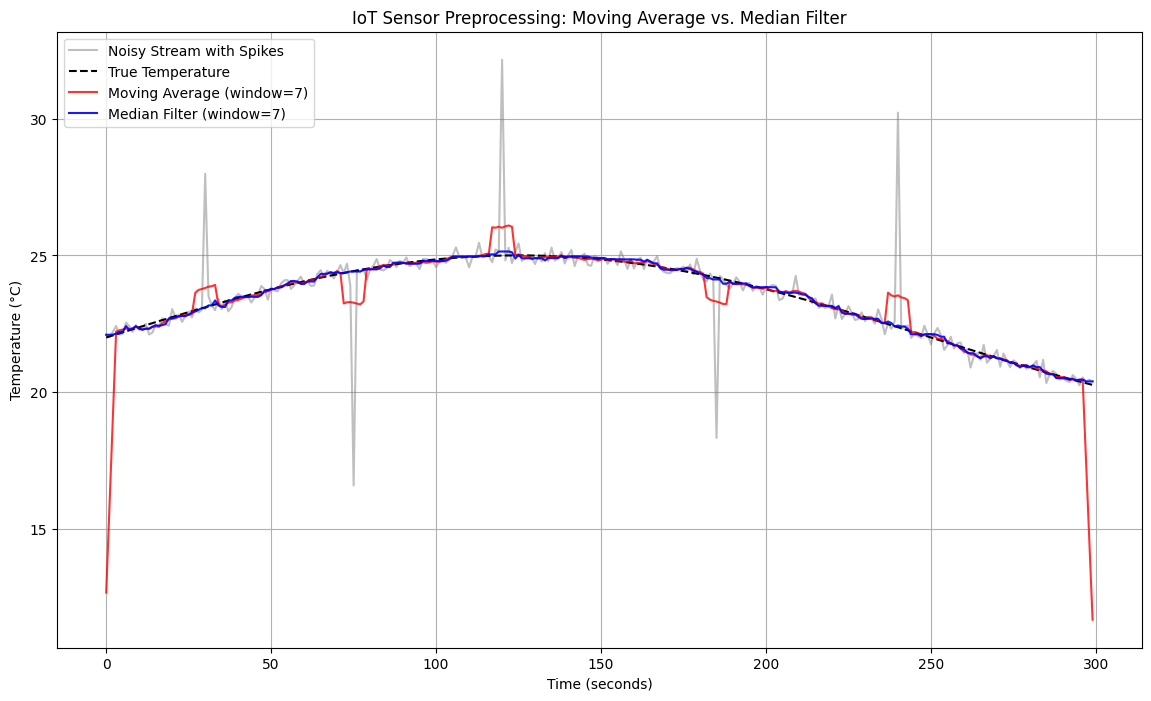

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# 1. Generate Simulated Temperature Stream (fs = 1 Hz, 5 minutes)
fs = 1.0  # 1 sample per second
t = np.arange(0, 300, 1/fs)  # 300 seconds

# True temperature profile (diurnal cycle simulation)
true_temp = 22.0 + 3.0 * np.sin(2 * np.pi * 0.002 * t)

# Add Gaussian noise
np.random.seed(42)
noisy_temp = true_temp + np.random.normal(0, 0.2, len(t))

# Inject sparse impulse spikes (sensor/transmission errors)
spike_indices = [30, 75, 120, 185, 240]
noisy_temp[spike_indices] += np.array([5.0, -8.0, 7.0, -6.0, 8.0])

# 2. Custom Moving Average Filter
def moving_average(x, window_size):
    # Circular/zero padding to keep output length the same as input
    window = np.ones(window_size) / window_size
    return np.convolve(x, window, mode='same')

# 3. Custom Median Filter
def median_filter(x, window_size):
    # Slide window of odd size, find median
    pad_width = window_size // 2
    padded = np.pad(x, pad_width, mode='edge')
    y = np.zeros_like(x)
    for i in range(len(x)):
        y[i] = np.median(padded[i : i + window_size])
    return y

window_size = 7
ma_filtered = moving_average(noisy_temp, window_size)
med_filtered = median_filter(noisy_temp, window_size)

# Plotting Comparison
plt.figure(figsize=(14, 8))
plt.plot(t, noisy_temp, 'gray', alpha=0.5, label='Noisy Stream with Spikes')
plt.plot(t, true_temp, 'black', linewidth=1.5, label='True Temperature', linestyle='--')
plt.plot(t, ma_filtered, 'red', label=f'Moving Average (window={window_size})', alpha=0.8)
plt.plot(t, med_filtered, 'blue', label=f'Median Filter (window={window_size})', alpha=0.9)

plt.title("IoT Sensor Preprocessing: Moving Average vs. Median Filter")
plt.xlabel("Time (seconds)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

### Observation:
- Notice how the **Moving Average** filter is severely pulled away by the impulse spikes, creating broad bumps in the cleaned signal.
- The **Median Filter** completely rejects the spikes while keeping the signal closely aligned with the true profile.

## 2. Decimation (Downsampling) and Aliasing
**Downsampling** by an integer factor $M$ consists of keeping only every $M$-th sample of a discrete-time signal:
$$y[n] = x[nM]$$

According to the Nyquist theorem, if the original signal $x[n]$ is sampled at $f_s$, the new Nyquist limit after downsampling will be $f_s / (2M)$. Any frequency component in $x[n]$ above this new limit will wrap around and alias into the signal.

To prevent this, we must apply a low-pass filter (anti-aliasing filter) with a cutoff frequency of $f_c \le f_s / (2M)$ *before* downsampling. The combined process of low-pass filtering and downsampling is called **decimation**.

Let's see this in action by downsampling a signal with low and high frequency components.

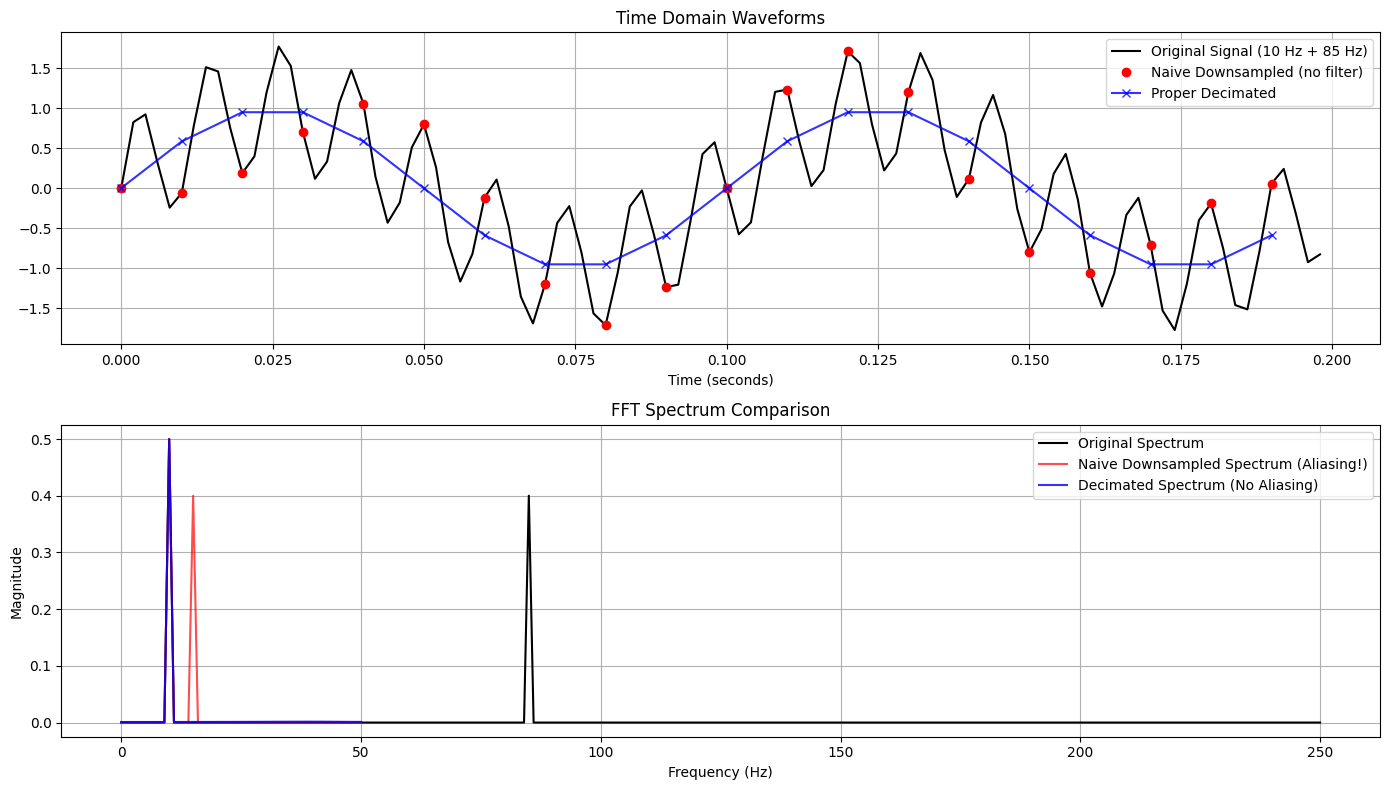

In [2]:
# Generate multi-tone signal: 10 Hz (desired) and 85 Hz (high frequency noise)
fs = 500.0  # 500 Hz sampling rate
t_signal = np.arange(0, 1.0, 1/fs)
x = np.sin(2 * np.pi * 10 * t_signal) + 0.8 * np.sin(2 * np.pi * 85 * t_signal)

M = 5  # Downsample factor
fs_new = fs / M  # 100 Hz sampling rate (New Nyquist = 50 Hz)

# 1. Naive Downsampling (Simply taking every M-th sample)
x_naive = x[::M]
t_new = t_signal[::M]

# 2. Proper Decimation (Anti-aliasing lowpass filter + downsampling)
# Design low-pass butterworth filter (cutoff at 45 Hz, slightly below new Nyquist limit 50 Hz)
nyq = 0.5 * fs
b_aa, a_aa = signal.butter(6, 45.0 / nyq, btype='low')
x_filtered = signal.filtfilt(b_aa, a_aa, x)
x_decimated = x_filtered[::M]

# Compute frequency spectrums using FFT
def get_spectrum(signal_data, sampling_rate):
    N = len(signal_data)
    freqs = np.fft.rfftfreq(N, 1/sampling_rate)
    fft_val = np.abs(np.fft.rfft(signal_data)) / N
    return freqs, fft_val

freqs_orig, fft_orig = get_spectrum(x, fs)
freqs_naive, fft_naive = get_spectrum(x_naive, fs_new)
freqs_dec, fft_dec = get_spectrum(x_decimated, fs_new)

# Plotting Spectral Analysis
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(t_signal[:100], x[:100], 'black', label='Original Signal (10 Hz + 85 Hz)')
plt.plot(t_new[:20], x_naive[:20], 'red', marker='o', label='Naive Downsampled (no filter)', linestyle='None')
plt.plot(t_new[:20], x_decimated[:20], 'blue', marker='x', label='Proper Decimated', alpha=0.8)
plt.title("Time Domain Waveforms")
plt.xlabel("Time (seconds)")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freqs_orig, fft_orig, 'black', label='Original Spectrum')
plt.plot(freqs_naive, fft_naive, 'red', label='Naive Downsampled Spectrum (Aliasing!)', alpha=0.7)
plt.plot(freqs_dec, fft_dec, 'blue', label='Decimated Spectrum (No Aliasing)', alpha=0.8)
plt.title("FFT Spectrum Comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Mathematical check on Aliasing:
- Our new sampling rate is $100$ Hz, so the folding frequency is $50$ Hz.
- The original signal had an $85$ Hz component. Since $85 > 50$, it aliases to $|85 - 100| = 15$ Hz.
- Look at the red curve in the spectrum plot: there is a fake spike at **$15$ Hz**. In the time domain, this causes the naive downsampled signal to oscillate incorrectly.
- The blue curve (proper decimation) has filtered out the 85 Hz component, leaving a clean 10 Hz signal without aliasing distortion.

## 3. Interpolation (Upsampling)
**Interpolation** by an integer factor $L$ is the process of increasing the sampling rate by:
1. **Zero-insertion**: Insert $L-1$ zeros between consecutive samples. If $x[n]$ is the original signal, the zero-stuffed signal $w[n]$ is:
   $$w[n] = \begin{cases} x[n/L], & n = 0, \pm L, \pm 2L, \dots \\ 0, & \text{otherwise} \end{cases}$$
   This operation preserves the shape of the spectrum but creates $L-1$ spectral images at higher frequencies.
2. **Interpolation Filtering**: Filter out the spectral images using a low-pass filter with a cutoff frequency of $f_s / (2)$ (the original Nyquist frequency) and a gain of $L$ (to compensate for the zero-stuffing amplitude drop).

Let's implement this upsampling process.

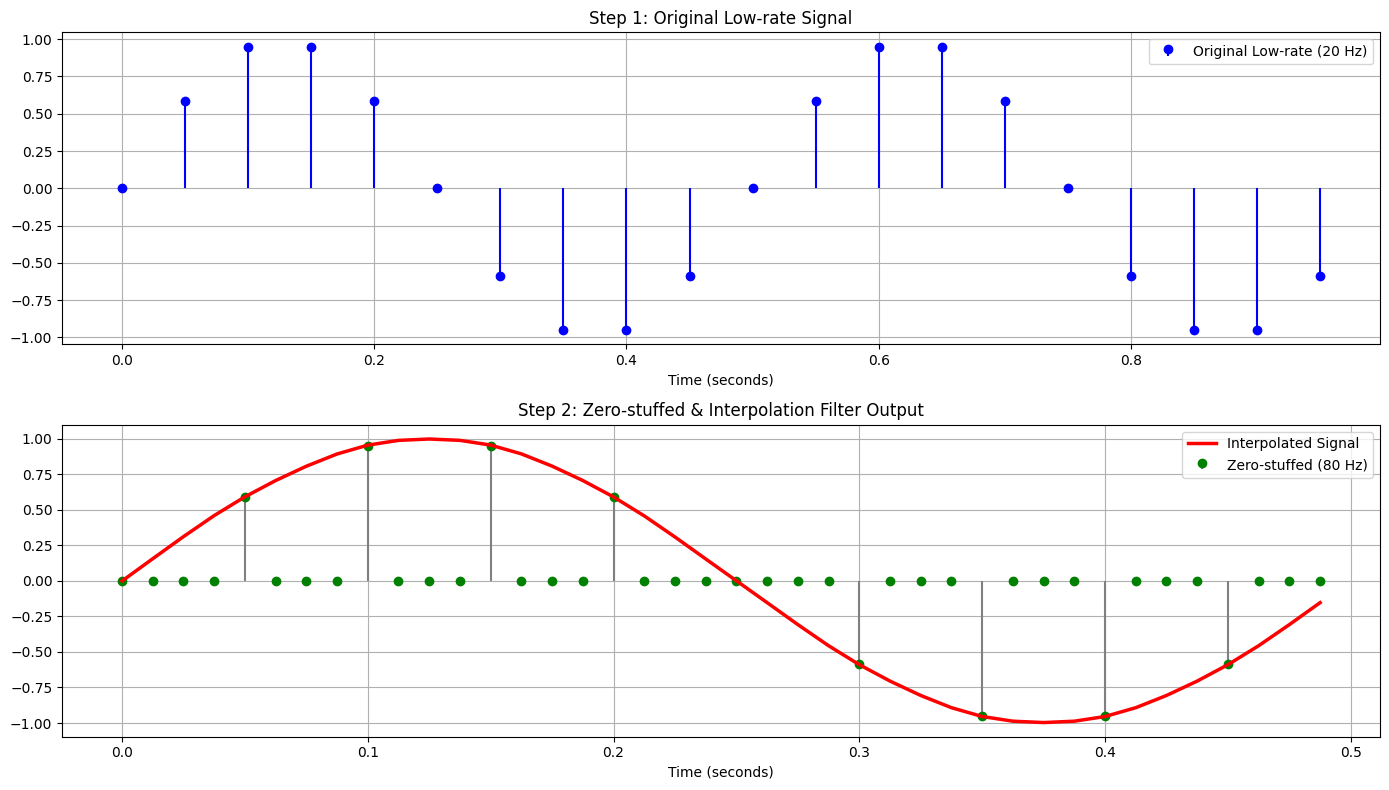

In [3]:
# Generate low-rate signal (fs = 20 Hz, sine wave of 2 Hz)
fs_low = 20.0
t_low = np.arange(0, 1.0, 1/fs_low)
x_low = np.sin(2 * np.pi * 2 * t_low)

L = 4  # Upsample factor
fs_high = fs_low * L  # 80 Hz new sampling rate

# 1. Zero Stuffing
w = np.zeros(len(x_low) * L)
w[::L] = x_low
t_high = np.arange(0, len(w)) / fs_high

# 2. Design Interpolation Filter (cutoff at fs_low/2 = 10 Hz, filter gain = L)
nyq_high = 0.5 * fs_high
b_interp, a_interp = signal.butter(4, 10.0 / nyq_high, btype='low')

# Apply filter and multiply by L to restore signal amplitude
x_interpolated = signal.filtfilt(b_interp, a_interp, w) * L

# Plotting the steps
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.stem(t_low, x_low, linefmt='blue', markerfmt='bo', basefmt=' ', label='Original Low-rate (20 Hz)')
plt.title("Step 1: Original Low-rate Signal")
plt.xlabel("Time (seconds)")
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.stem(t_high[:40], w[:40], linefmt='gray', markerfmt='go', basefmt=' ', label='Zero-stuffed (80 Hz)')
plt.plot(t_high[:40], x_interpolated[:40], 'red', label='Interpolated Signal', linewidth=2.5)
plt.title("Step 2: Zero-stuffed & Interpolation Filter Output")
plt.xlabel("Time (seconds)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Multi-Sensor Sampling Rate Alignment
In IoT applications (e.g. Activity Tracking), we often fuse data from sensors that run on different clocks (e.g., Accelerometer at 50 Hz and Gyroscope at 10 Hz).

To feed these into a machine learning model or compute correlations, they must share the exact same timestamp coordinates. We can align the Gyroscope to the Accelerometer's rate of 50 Hz by interpolating it by $L = 5$.

Original Acc shape: (150,)
Original Gyro shape: (30,)
Aligned Gyro shape: (150,)


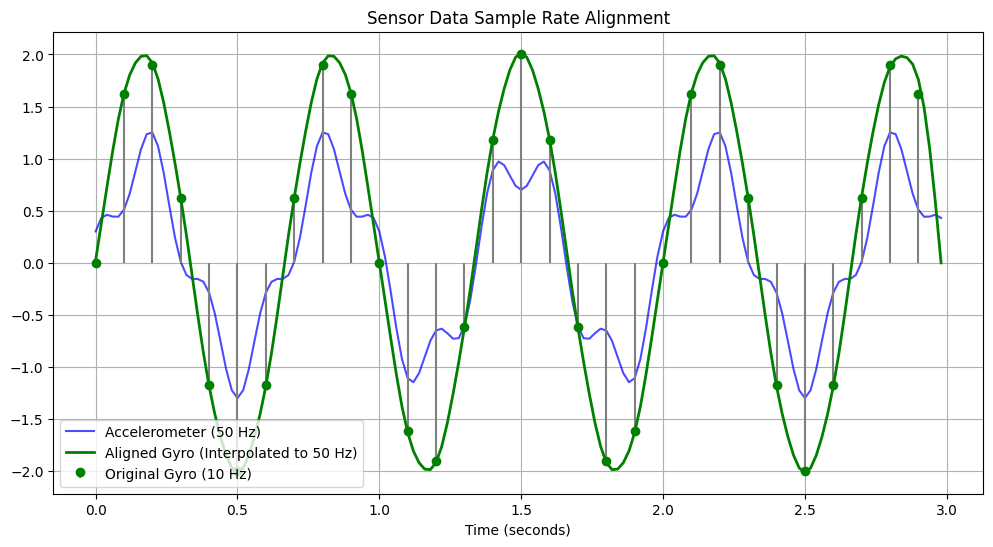

In [4]:
# Simulate shared time range: 3 seconds
duration = 3.0

# Sensor A: Accelerometer (fs = 50 Hz, 150 samples)
fs_acc = 50.0
t_acc = np.linspace(0, duration, int(duration * fs_acc), endpoint=False)
# Physical signal: user body movement simulation
acc_data = np.sin(2 * np.pi * 1.5 * t_acc) + 0.3 * np.cos(2 * np.pi * 5 * t_acc)

# Sensor B: Gyroscope (fs = 10 Hz, 30 samples)
fs_gyro = 10.0
t_gyro = np.linspace(0, duration, int(duration * fs_gyro), endpoint=False)
gyro_data = 2.0 * np.sin(2 * np.pi * 1.5 * t_gyro)

# Align Gyroscope to 50 Hz by upsampling by L = 5
L_align = 5
gyro_zero_stuffed = np.zeros(len(gyro_data) * L_align)
gyro_zero_stuffed[::L_align] = gyro_data

nyq_acc = 0.5 * fs_acc
b_gyro, a_gyro = signal.butter(4, 5.0 / nyq_acc, btype='low')  # Cutoff at 5 Hz (Nyquist of original Gyro rate)
gyro_aligned = signal.filtfilt(b_gyro, a_gyro, gyro_zero_stuffed) * L_align

print(f"Original Acc shape: {acc_data.shape}")
print(f"Original Gyro shape: {gyro_data.shape}")
print(f"Aligned Gyro shape: {gyro_aligned.shape}")

# Plot aligned data
plt.figure(figsize=(12, 6))
plt.plot(t_acc, acc_data, label='Accelerometer (50 Hz)', color='blue', alpha=0.7)
plt.stem(t_gyro, gyro_data, linefmt='gray', markerfmt='go', label='Original Gyro (10 Hz)', basefmt=' ')
plt.plot(t_acc, gyro_aligned, label='Aligned Gyro (Interpolated to 50 Hz)', color='green', linewidth=2)
plt.title("Sensor Data Sample Rate Alignment")
plt.xlabel("Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()

## ✅ Reflection & Exercises
- **Decimation Aliasing**: Run Section 2 with different downsample factors (e.g. $M = 10$). What frequency does the $85$ Hz tone alias to when $f_{s}' = 50$ Hz? Confirm mathematically.
- **Filter Choice**: Why is the Median Filter non-linear? (Hint: Does it obey the superposition principle? Test if $Median(A + B) = Median(A) + Median(B)$).